# Part 4 — Vector Databases: Embeddings Demo
This notebook demonstrates how sentence embeddings capture semantic meaning.
We use the `all-MiniLM-L6-v2` model from `sentence-transformers` to:
- Generate embeddings for 10 sentences across 3 topics
- Compute a 10x10 cosine similarity matrix
- Visualise it as a heatmap
- Find the top 2 most similar sentences to a query

In [9]:
# Install required libraries
!pip install sentence-transformers seaborn matplotlib -q

In [10]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [11]:
# 10 sentences across 3 topics: Cricket, Cooking, Cybersecurity
sentences = [
    # Cricket (4 sentences)
    'The batsman hit a magnificent six over the long-on boundary.',
    'India won the test match by an innings and fifty runs.',
    'The bowler took three wickets in one over.',
    'A dropped catch in the final over cost the team the match.',

    # Cooking (3 sentences)
    'Saute the onions in olive oil until they turn golden brown.',
    'Always preheat the oven before baking a cake.',
    'Add a pinch of salt to the boiling pasta water for better flavour.',

    # Cybersecurity (3 sentences)
    'A phishing attack tricked employees into revealing their passwords.',
    'Always use two-factor authentication to protect your accounts.',
    'The firewall blocked several unauthorised intrusion attempts overnight.'
]

# Short labels for heatmap axes
labels = [
    'Cricket-1', 'Cricket-2', 'Cricket-3', 'Cricket-4',
    'Cooking-1', 'Cooking-2', 'Cooking-3',
    'Cyber-1',   'Cyber-2',   'Cyber-3'
]

print(f'Total sentences: {len(sentences)}')

Total sentences: 10


In [12]:
# Load the model and generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

print(f'Embedding shape: {embeddings.shape}')
print('Embeddings generated successfully!')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: torch.Size([10, 384])
Embeddings generated successfully!


In [13]:
# Compute 10x10 cosine similarity matrix
cosine_scores = util.cos_sim(embeddings, embeddings).numpy()

print('Cosine Similarity Matrix (10x10):')
print(np.round(cosine_scores, 2))

Cosine Similarity Matrix (10x10):
[[ 1.    0.45  0.57  0.24  0.    0.   -0.06  0.02 -0.03  0.05]
 [ 0.45  1.    0.58  0.36  0.02  0.02 -0.04  0.07 -0.07  0.08]
 [ 0.57  0.58  1.    0.34  0.09  0.03  0.04  0.1  -0.04  0.03]
 [ 0.24  0.36  0.34  1.   -0.08 -0.04  0.    0.13 -0.04  0.14]
 [ 0.    0.02  0.09 -0.08  1.    0.25  0.32  0.11 -0.02  0.01]
 [ 0.    0.02  0.03 -0.04  0.25  1.    0.19  0.07  0.15  0.02]
 [-0.06 -0.04  0.04  0.    0.32  0.19  1.    0.04  0.06 -0.  ]
 [ 0.02  0.07  0.1   0.13  0.11  0.07  0.04  1.    0.33  0.34]
 [-0.03 -0.07 -0.04 -0.04 -0.02  0.15  0.06  0.33  1.    0.24]
 [ 0.05  0.08  0.03  0.14  0.01  0.02 -0.    0.34  0.24  1.  ]]


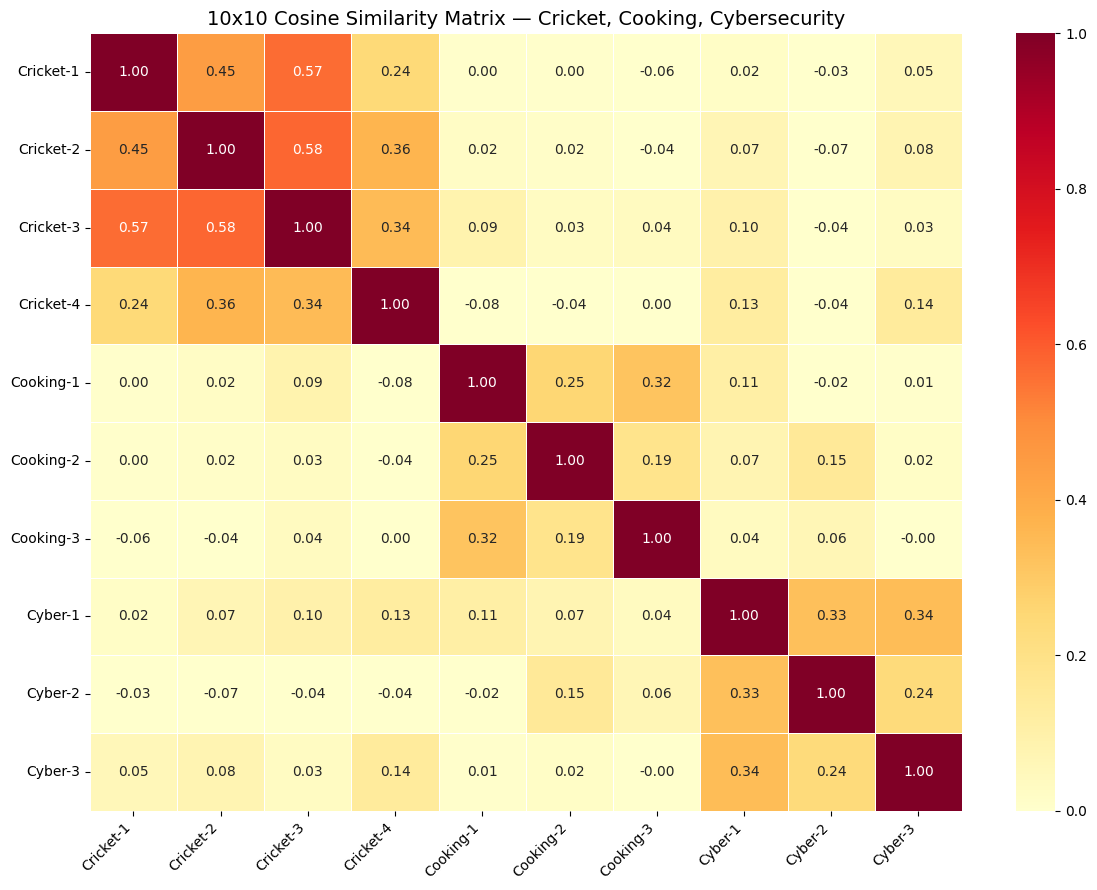

In [14]:
# Visualise as a heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    cosine_scores,
    annot=True,
    fmt='.2f',
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0,
    vmax=1
)
plt.title('10x10 Cosine Similarity Matrix — Cricket, Cooking, Cybersecurity', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
# Query sentence — find top 2 most similar sentences
query = 'The bowler took three wickets in one over'
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute similarity between query and all 10 sentences
query_scores = util.cos_sim(query_embedding, embeddings)[0].numpy()

# Sort by similarity (descending), skip index 2 (the sentence itself)
ranked_indices = np.argsort(query_scores)[::-1]
ranked_indices = [i for i in ranked_indices if sentences[i] != query]

print(f'Query: "{query}"')
print()
print('Top 2 Most Similar Sentences:')
for rank, idx in enumerate(ranked_indices[:2], start=1):
    print(f'{rank}. [{labels[idx]}] "{sentences[idx]}"')
    print(f'   Similarity Score: {query_scores[idx]:.4f}')
    print()

Query: "The bowler took three wickets in one over"

Top 2 Most Similar Sentences:
1. [Cricket-3] "The bowler took three wickets in one over."
   Similarity Score: 0.9914

2. [Cricket-2] "India won the test match by an innings and fifty runs."
   Similarity Score: 0.5592

